# Visualizations 
This notebook evaluates:
- **TD-A**: DistilBERT(best) vs T5(best)
- **TD-B**: ChatGPT vs LLaMA vs DistilBERT(best) vs T5(best)

## Folder layout expected
```
project/
  best_checkpoint_distillbert/
  best_checkpoint_t5/
  local_squad/td_a_validation.json
  local_squad/td_b_100.json
  results/tdb_compare_4models.json   (created by compare_models.py)
```

### We first load the fine-tuned and large language models and run them on the TD-A and TD-B test sets in order to generate comparable answer predictions. These predictions form the basis for all subsequent quantitative and qualitative analyses.

In [4]:

from pathlib import Path
import re, json
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, AutoModelForSeq2SeqLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------
# 🔧 EDIT PATHS IF NEEDED
# -------------------------
DISTILBERT_PATH = Path("best_checkpoint_distillbert")
T5_PATH         = Path("best_checkpoint_t5")

TD_A_JSON        = Path("local_squad/td_a_validation.json")
TD_B_JSON        = Path("local_squad/td_b_100.json")

TDB_COMPARE_JSON = Path("results/tdb_compare_4models.json")  # from compare_models.py

# -------------------------
# SQuAD metrics
# -------------------------
def normalize_answer(s: str) -> str:
    import string
    def lower(text): return text.lower()
    def remove_punc(text): return "".join(ch for ch in text if ch not in set(string.punctuation))
    def remove_articles(text): return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text): return " ".join(text.split())
    return white_space_fix(remove_articles(remove_punc(lower(s or ""))))

def f1_score(prediction: str, ground_truth: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if len(pred_tokens) == 0 and len(gt_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return 0.0
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

def exact_match_score(prediction: str, ground_truth: str) -> float:
    return 1.0 if normalize_answer(prediction) == normalize_answer(ground_truth) else 0.0

def metric_max_over_ground_truths(metric_fn, prediction: str, ground_truths):
    return max(metric_fn(prediction, gt) for gt in ground_truths) if ground_truths else metric_fn(prediction, "")

def eval_em_f1(preds_by_id, examples):
    total = len(examples)
    em_sum = 0.0
    f1_sum = 0.0
    for ex in examples:
        qid = ex["id"]
        pred = preds_by_id.get(qid, "")
        golds = ex.get("answers", {}).get("text", []) or [""]
        em_sum += metric_max_over_ground_truths(exact_match_score, pred, golds)
        f1_sum += metric_max_over_ground_truths(f1_score, pred, golds)
    return {"n": total, "em": 100.0 * em_sum / total if total else 0.0, "f1": 100.0 * f1_sum / total if total else 0.0}

# -------------------------
# Data loading
# -------------------------
def load_flat_squad(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path.resolve()}")
    data = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(data, list) or not data:
        raise ValueError(f"{path} must be a non-empty list JSON.")
    # minimal sanity
    for ex in data[:2]:
        for k in ["id","context","question","answers"]:
            assert k in ex, f"Missing key {k} in {path}"
    return data

print("✅ Setup complete.")


DEVICE: cuda
✅ Setup complete.


In [5]:

# =========================
# TD-A: evaluate best DistilBERT + best T5
# =========================
td_a = load_flat_squad(TD_A_JSON)
print("TD-A N =", len(td_a))

# ---- DistilBERT decoding (extractive QA) ----
@torch.inference_mode()
def predict_answers_distilbert(
    model,
    tokenizer,
    examples,
    device: str,
    max_length: int = 384,
    doc_stride: int = 128,
    max_answer_length: int = 30,
    batch_size: int = 16,
    top_k: int = 20,
):
    questions = [ex["question"] for ex in examples]
    contexts = [ex["context"] for ex in examples]
    ids = [ex["id"] for ex in examples]

    enc = tokenizer(
        questions,
        contexts,
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
        return_tensors=None,
    )

    overflow_to_sample = enc["overflow_to_sample_mapping"]
    offset_mapping = enc["offset_mapping"]
    input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
    attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)

    model.to(device).eval()
    best = {qid: {"score": -1e18, "text": ""} for qid in ids}

    nfeat = input_ids.size(0)
    for start in tqdm(range(0, nfeat, batch_size), desc="DistilBERT QA (TD-A)"):
        end = min(start + batch_size, nfeat)
        batch = {
            "input_ids": input_ids[start:end].to(device),
            "attention_mask": attention_mask[start:end].to(device),
        }
        out = model(**batch)
        s_logits = out.start_logits.detach().cpu()
        e_logits = out.end_logits.detach().cpu()

        for i in range(end - start):
            feature_idx = start + i
            sample_idx = int(overflow_to_sample[feature_idx])
            qid = ids[sample_idx]

            offsets = offset_mapping[feature_idx]
            seq_ids = enc.sequence_ids(feature_idx)
            context_token_indices = [j for j, s in enumerate(seq_ids) if s == 1]
            if not context_token_indices:
                continue

            s_log = s_logits[i].tolist()
            e_log = e_logits[i].tolist()

            start_c = sorted(range(len(s_log)), key=lambda j: s_log[j], reverse=True)[:top_k]
            end_c   = sorted(range(len(e_log)), key=lambda j: e_log[j], reverse=True)[:top_k]

            for s_idx in start_c:
                for e_idx in end_c:
                    if s_idx not in context_token_indices or e_idx not in context_token_indices:
                        continue
                    if e_idx < s_idx:
                        continue
                    if (e_idx - s_idx + 1) > max_answer_length:
                        continue

                    s_off = offsets[s_idx]
                    e_off = offsets[e_idx]
                    if s_off is None or e_off is None:
                        continue

                    char_s = s_off[0]
                    char_e = e_off[1]
                    if char_s is None or char_e is None or char_e <= char_s:
                        continue

                    text = contexts[sample_idx][char_s:char_e]
                    score = s_log[s_idx] + e_log[e_idx]
                    if score > best[qid]["score"]:
                        best[qid] = {"score": score, "text": text}

    return {qid: best[qid]["text"] for qid in best}

print("Loading DistilBERT best checkpoint...")
db_tok = AutoTokenizer.from_pretrained(DISTILBERT_PATH, use_fast=True)
db_model = AutoModelForQuestionAnswering.from_pretrained(DISTILBERT_PATH)

db_preds_tda = predict_answers_distilbert(db_model, db_tok, td_a, DEVICE)
db_metrics_tda = eval_em_f1(db_preds_tda, td_a)
db_metrics_tda


TD-A N = 10570
Loading DistilBERT best checkpoint...


DistilBERT QA (TD-A):   0%|          | 0/674 [00:00<?, ?it/s]

{'n': 10570, 'em': 76.08325449385052, 'f1': 84.72404087143947}

In [6]:

# ---- T5 decoding (generative QA) ----
def build_t5_prompt(q: str, c: str) -> str:
    return f"question: {q}  context: {c}"

@torch.inference_mode()
def predict_answers_t5(
    model,
    tokenizer,
    examples,
    device: str,
    input_max_length: int = 512,
    batch_size: int = 8,
    gen_max_new_tokens: int = 32,
    gen_max_length: int = 64,   # fallback
    num_beams: int = 1,
):
    ids = [ex["id"] for ex in examples]
    prompts = [build_t5_prompt(ex["question"], ex["context"]) for ex in examples]

    model.to(device).eval()
    preds = {}

    for start in tqdm(range(0, len(prompts), batch_size), desc="T5 generate (TD-A)"):
        end = min(start + batch_size, len(prompts))
        enc = tokenizer(
            prompts[start:end],
            truncation=True,
            max_length=input_max_length,
            padding=True,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        early_stopping = True if num_beams > 1 else False

        try:
            gen_ids = model.generate(
                **enc,
                max_new_tokens=gen_max_new_tokens,
                num_beams=num_beams,
                early_stopping=early_stopping,
                do_sample=False,
            )
        except TypeError:
            gen_ids = model.generate(
                **enc,
                max_length=gen_max_length,
                num_beams=num_beams,
                early_stopping=early_stopping,
                do_sample=False,
            )

        texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
        for qid, txt in zip(ids[start:end], texts):
            preds[qid] = (txt or "").strip()

    return preds

print("Loading T5 best checkpoint...")
t5_tok = AutoTokenizer.from_pretrained(T5_PATH, use_fast=True)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_PATH)

t5_preds_tda = predict_answers_t5(t5_model, t5_tok, td_a, DEVICE)
t5_metrics_tda = eval_em_f1(t5_preds_tda, td_a)
t5_metrics_tda


Loading T5 best checkpoint...


T5 generate (TD-A):   0%|          | 0/1322 [00:00<?, ?it/s]

{'n': 10570, 'em': 76.92526017029329, 'f1': 85.57052397435905}

### We first compare the performance of the two fine-tuned models, DistilBERT and T5, on the TD-A validation set.

In [16]:

# =========================
# TD-A: comparison table + plots
# =========================
tda_df = pd.DataFrame([
    {"model":"DistilBERT", "em": db_metrics_tda["em"], "f1": db_metrics_tda["f1"]},
    {"model":"T5",         "em": t5_metrics_tda["em"], "f1": t5_metrics_tda["f1"]},
]).sort_values("f1", ascending=False)

tda_df[["em", "f1"]] = tda_df[["em", "f1"]].round(2)

tda_df


,model,em,f1
1,T5,76.93,85.57
0,DistilBERT,76.08,84.72


### We now load the TD-B results for all four models to compare LLMs with fine-tuned QA models.

In [21]:

# =========================
# TD-B: load 4-model comparison JSON (from compare_models.py)
# =========================
if not TDB_COMPARE_JSON.exists():
    raise FileNotFoundError(
        f"Missing: {TDB_COMPARE_JSON.resolve()}\n"
        f"Run: python compare_models.py (it should create results/tdb_compare_4models.json)"
    )

payload = json.loads(TDB_COMPARE_JSON.read_text(encoding="utf-8"))
metrics = payload.get("metrics", {})

tdb_rows = []
for key, label in [
    ("chatgpt", "ChatGPT 5.2"),
    ("llama", "LLaMA-2-7B-Chat"),
    ("distilbert", "DistilBERT"),
    ("t5", "T5"),
]:
    m = metrics.get(key, {})
    tdb_rows.append({
        "model": label,
        "em": float(m.get("em", np.nan)),
        "f1": float(m.get("f1", np.nan)),
    })

tdb_df = pd.DataFrame(tdb_rows).sort_values("f1", ascending=False).reset_index(drop=True)
tdb_df[["em", "f1"]] = tdb_df[["em", "f1"]].round(2)
tdb_df


,model,em,f1
0,DistilBERT,83.0,90.39
1,ChatGPT 5.2,77.0,88.01
2,T5,76.0,83.26
3,LLaMA-2-7B-Chat,68.0,74.96


### The following plot highlights performance differences between the four models on TD-B by directly comparing their F1 and Exact Match scores.

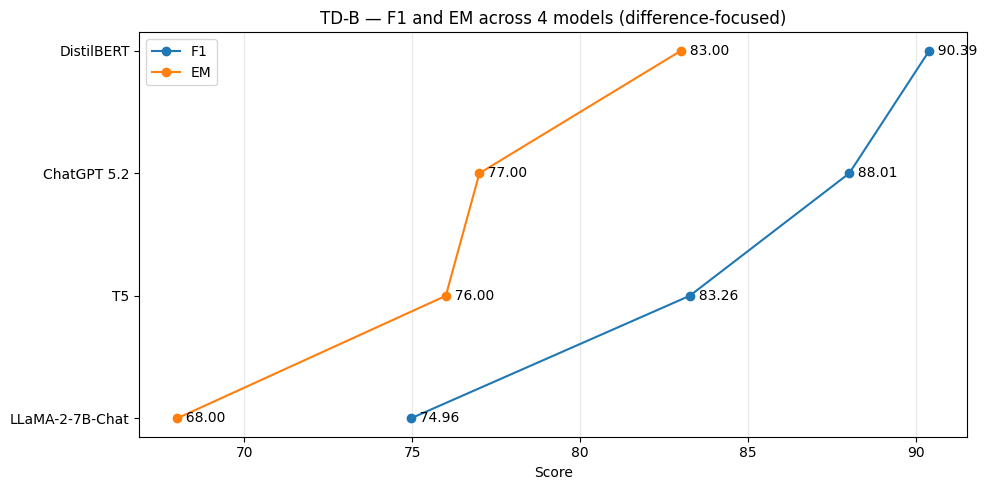

In [22]:
import matplotlib.pyplot as plt

tdb_plot = tdb_df.sort_values("f1", ascending=True).reset_index(drop=True)  # ascending for nicer y order

plt.figure(figsize=(10, 5))
y = range(len(tdb_plot))

plt.plot(tdb_plot["f1"], y, marker="o", label="F1")
plt.plot(tdb_plot["em"], y, marker="o", label="EM")

for i, (f1, em) in enumerate(zip(tdb_plot["f1"], tdb_plot["em"])):
    plt.text(f1, i, f"  {f1:.2f}", va="center")
    plt.text(em, i, f"  {em:.2f}", va="center")

plt.yticks(y, tdb_plot["model"])
plt.title("TD-B — F1 and EM across 4 models (difference-focused)")
plt.xlabel("Score")
plt.grid(True, axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### This grouped bar chart compares F1 and Exact Match for all four models on TD-B, enabling a direct side-by-side performance comparison.

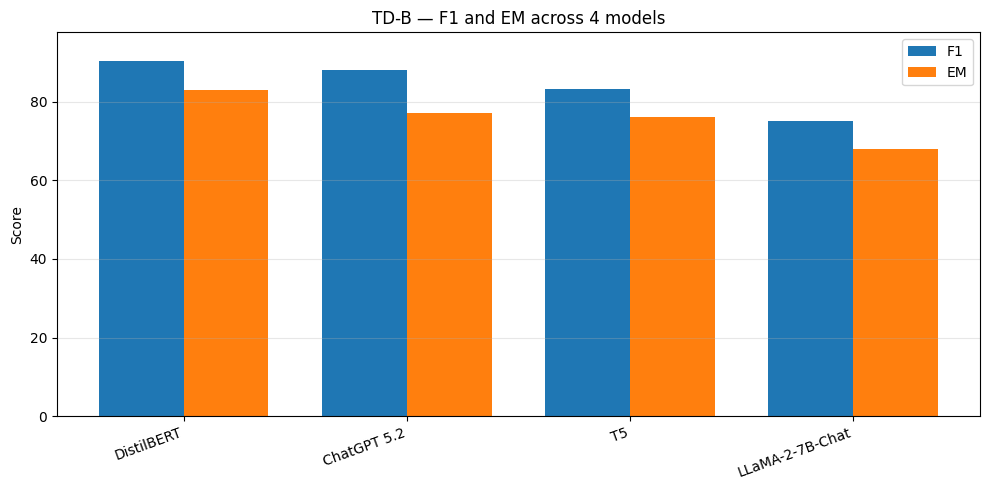

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ensure order is best->worst by F1
tdb_plot = tdb_df.sort_values("f1", ascending=False).reset_index(drop=True)

x = np.arange(len(tdb_plot))
w = 0.38  # bar width

plt.figure(figsize=(10, 5))
plt.bar(x - w/2, tdb_plot["f1"], width=w, label="F1")
plt.bar(x + w/2, tdb_plot["em"], width=w, label="EM")

plt.title("TD-B — F1 and EM across 4 models")
plt.ylabel("Score")
plt.ylim(0, max(tdb_plot[["f1","em"]].max()) * 1.08)

plt.xticks(x, tdb_plot["model"], rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### We now compare the fine-tuned models across TD-A and TD-B to examine whether their relative ranking remains consistent between the two evaluation sets.

In [24]:
# =========================
# TD-A vs TD-B: do rankings match for the fine-tuned models?
# =========================

# Keep only DistilBERT and T5 from TD-B
tdb_ft = tdb_df[tdb_df["model"].isin(["DistilBERT", "T5"])].copy()

# Sort both tables by model name to guarantee correct alignment
tda_ft = tda_df.sort_values("model").reset_index(drop=True)
tdb_ft = tdb_ft.sort_values("model").reset_index(drop=True)

# Merge on model name
merged = pd.merge(
    tda_ft,
    tdb_ft[["model", "em", "f1"]],
    on="model",
    how="left",
    suffixes=("_tdA", "_tdB"),
)

# Round all metric columns to 2 decimals
merged[["em_tdA", "f1_tdA", "em_tdB", "f1_tdB"]] = \
    merged[["em_tdA", "f1_tdA", "em_tdB", "f1_tdB"]].round(2)

merged


,model,em_tdA,f1_tdA,em_tdB,f1_tdB
0,DistilBERT,76.08,84.72,83.0,90.39
1,T5,76.93,85.57,76.0,83.26


Both fine-tuned models improve on the TD-B subset compared to TD-A, but DistilBERT shows a stronger relative gain, overtaking T5 and achieving the highest F1 and EM on TD-B.

### The following figure visualizes how the performance of the fine-tuned models changes from TD-A to TD-B for both F1 and Exact Match.

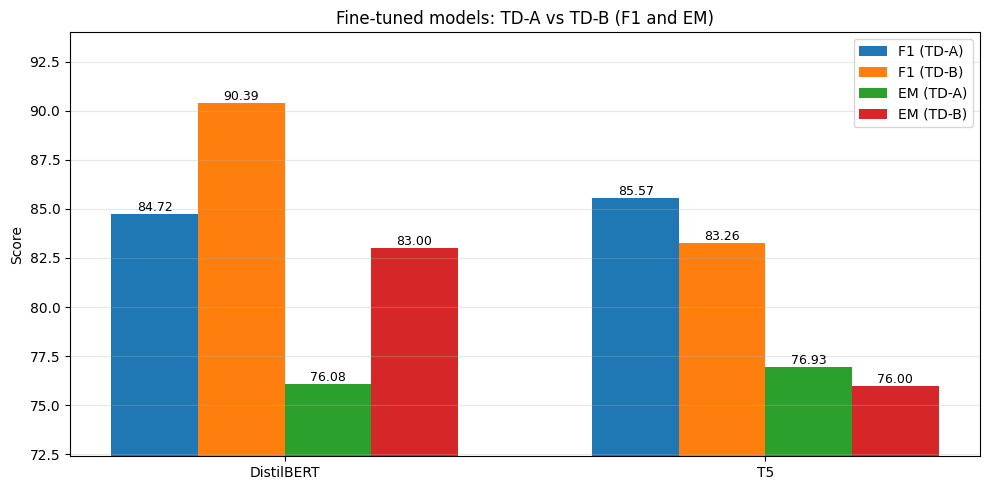

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure consistent order
plot_df = merged.sort_values("model").reset_index(drop=True)

models = plot_df["model"].tolist()

f1_a = plot_df["f1_tdA"].astype(float).to_numpy()
f1_b = plot_df["f1_tdB"].astype(float).to_numpy()
em_a = plot_df["em_tdA"].astype(float).to_numpy()
em_b = plot_df["em_tdB"].astype(float).to_numpy()

x = np.arange(len(models))
w = 0.18

plt.figure(figsize=(10, 5))

b1 = plt.bar(x - 1.5*w, f1_a, width=w, label="F1 (TD-A)")
b2 = plt.bar(x - 0.5*w, f1_b, width=w, label="F1 (TD-B)")
b3 = plt.bar(x + 0.5*w, em_a, width=w, label="EM (TD-A)")
b4 = plt.bar(x + 1.5*w, em_b, width=w, label="EM (TD-B)")

# Value labels (rounded to 2 decimals)
def add_labels(bars):
    for bar in bars:
        v = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            v,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(b1); add_labels(b2); add_labels(b3); add_labels(b4)

plt.title("Fine-tuned models: TD-A vs TD-B (F1 and EM)")
plt.xticks(x, models, rotation=0)
plt.ylabel("Score")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

# Tight y-limits to emphasize differences (auto-detect 0..1 vs 0..100)
all_vals = np.concatenate([f1_a, f1_b, em_a, em_b])
vmin, vmax = float(np.min(all_vals)), float(np.max(all_vals))
margin = (vmax - vmin) * 0.25 if vmax > vmin else 0.05

if vmax <= 1.5:  # likely 0..1
    plt.ylim(max(0.0, vmin - margin), min(1.0, vmax + margin))
else:            # likely 0..100
    plt.ylim(max(0.0, vmin - margin), vmax + margin)

plt.tight_layout()
plt.show()


The bar chart confirms that DistilBERT gains more from TD-A to TD-B than T5, achieving higher F1 and EM on the reduced test set, while T5 shows a slight decrease, leading to a change in their relative ranking.

### We next compute a pairwise agreement matrix to analyze how often different models produce the same normalized answer for the same question.

In [28]:
import json
import numpy as np
import pandas as pd
import re, string
import matplotlib.pyplot as plt
from pathlib import Path

def normalize(s: str) -> str:
    s = (s or "").lower()
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = " ".join(s.split())
    return s

# ---- load
payload = json.loads(Path("results/tdb_compare_4models.json").read_text(encoding="utf-8"))
preds_by_model = payload["preds"]   # model_key -> {qid -> answer}

model_keys = ["chatgpt", "llama", "distilbert", "t5"]
labels     = ["ChatGPT 5.2", "LLaMA-2-7B", "DistilBERT", "T5"]

# use intersection of qids that exist for all models
qid_sets = [set(preds_by_model[m].keys()) for m in model_keys]
qids = sorted(set.intersection(*qid_sets))
N = len(qids)

agree = np.zeros((len(model_keys), len(model_keys)), dtype=float)

for qid in qids:
    answers = [normalize(preds_by_model[m].get(qid, "")) for m in model_keys]
    for i in range(len(model_keys)):
        for j in range(len(model_keys)):
            agree[i, j] += (answers[i] == answers[j])

agree = agree / N

agree_df = pd.DataFrame(agree, index=labels, columns=labels).round(2)
agree_df


,ChatGPT 5.2,LLaMA-2-7B,DistilBERT,T5
ChatGPT 5.2,1.00,0.56,0.62,0.60
LLaMA-2-7B,0.56,1.00,0.59,0.57
DistilBERT,0.62,0.59,1.00,0.65
T5,0.60,0.57,0.65,1.00


DistilBERT and T5 exhibit the highest mutual agreement, indicating very similar answer behavior, while both LLMs show lower agreement with the fine-tuned models, reflecting differences between generative and extractive answering strategies.

### The following heatmap visualizes the pairwise agreement rates between all models on TD-B.

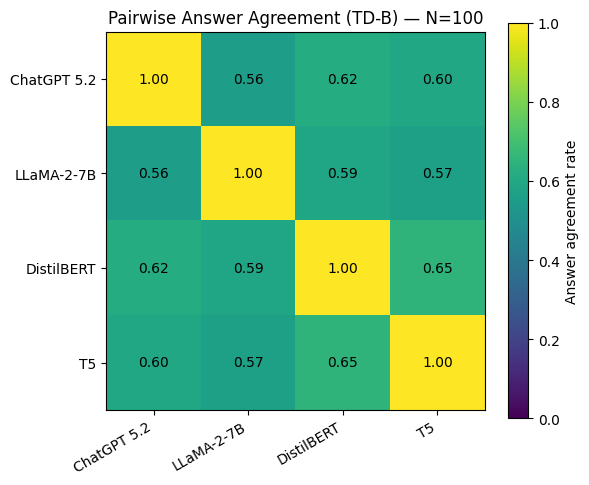

In [29]:
plt.figure(figsize=(6,5))
plt.imshow(agree, vmin=0, vmax=1)

plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{agree[i,j]:.2f}", ha="center", va="center", fontsize=10)

plt.colorbar(label="Answer agreement rate")
plt.title(f"Pairwise Answer Agreement (TD-B) — N={N}")
plt.tight_layout()
plt.show()


### The following chart shows how often each model achieves the highest F1 score across the TD-B questions, including ties where multiple models perform equally well.

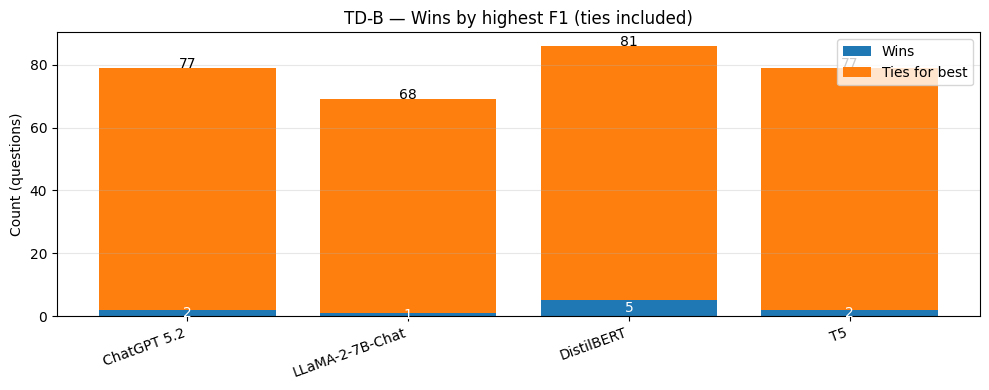

In [36]:
# ============================================================
# TD-B — Wins by highest F1 (ties included) — stacked bar chart
# Requires: per_q_df with column "winners"
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

model_cols = ["ChatGPT 5.2", "LLaMA-2-7B-Chat", "DistilBERT", "T5"]

def parse_winners(s):
    return [t.strip() for t in str(s).split(",") if t.strip()]

# Count wins and ties
win_counts = Counter()
tie_counts = Counter()

for w in per_q_df["winners"]:
    ws = parse_winners(w)
    if len(ws) == 1:
        win_counts[ws[0]] += 1
    else:
        for m in ws:
            tie_counts[m] += 1

wins = np.array([win_counts[m] for m in model_cols], dtype=int)
ties = np.array([tie_counts[m] for m in model_cols], dtype=int)

x = np.arange(len(model_cols))

plt.figure(figsize=(10, 4))
plt.bar(x, wins, label="Wins")
plt.bar(x, ties, bottom=wins, label="Ties for best")

plt.xticks(x, model_cols, rotation=20, ha="right")
plt.ylabel("Count (questions)")
plt.title("TD-B — Wins by highest F1 (ties included)")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

# Value labels
for i in range(len(model_cols)):
    if wins[i] > 0:
        plt.text(i, wins[i] / 2, str(wins[i]), ha="center", va="center", color="white", fontsize=10)
    if ties[i] > 0:
        plt.text(i, wins[i] + ties[i] - 1, str(ties[i]), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### We now analyze the distribution of answer lengths to compare the verbosity of LLMs with that of the fine-tuned extractive models.

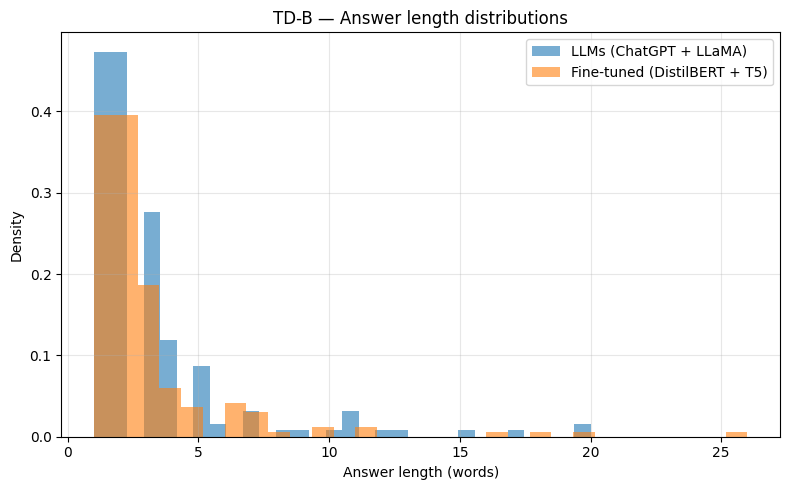

,group,mean_len,median_len,std_len
0,LLMs,3.04,2.0,3.09
1,Fine-tuned,2.84,2.0,3.13


In [37]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --------------------------
# Load predictions
# --------------------------
payload = json.loads(Path("results/tdb_compare_4models.json").read_text(encoding="utf-8"))
preds = payload["preds"]   # model_key -> {qid -> answer}

# --------------------------
# Tokenizer: simple word split
# --------------------------
def answer_length(s):
    if s is None:
        return 0
    s = s.strip()
    if not s:
        return 0
    return len(re.findall(r"\w+", s))

# --------------------------
# Collect lengths
# --------------------------
llm_models = ["chatgpt", "llama"]
ft_models  = ["distilbert", "t5"]

llm_lengths = []
ft_lengths  = []

# Use common question IDs
qids = set(preds["chatgpt"].keys())
for m in ["llama", "distilbert", "t5"]:
    qids &= set(preds[m].keys())

for qid in qids:
    for m in llm_models:
        llm_lengths.append(answer_length(preds[m][qid]))
    for m in ft_models:
        ft_lengths.append(answer_length(preds[m][qid]))

llm_lengths = np.array(llm_lengths)
ft_lengths  = np.array(ft_lengths)

# --------------------------
# Plot distributions
# --------------------------
plt.figure(figsize=(8,5))
plt.hist(llm_lengths, bins=30, alpha=0.6, density=True, label="LLMs (ChatGPT + LLaMA)")
plt.hist(ft_lengths, bins=30, alpha=0.6, density=True, label="Fine-tuned (DistilBERT + T5)")

plt.xlabel("Answer length (words)")
plt.ylabel("Density")
plt.title("TD-B — Answer length distributions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# Summary stats for report
# --------------------------
import pandas as pd

summary = pd.DataFrame({
    "group": ["LLMs", "Fine-tuned"],
    "mean_len": [llm_lengths.mean(), ft_lengths.mean()],
    "median_len": [np.median(llm_lengths), np.median(ft_lengths)],
    "std_len": [llm_lengths.std(), ft_lengths.std()],
}).round(2)

summary


### We next identify the hardest questions by counting how many models fail to answer each question correctly.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_cols = ["ChatGPT 5.2", "LLaMA-2-7B-Chat", "DistilBERT", "T5"]

# Count misses (F1 == 0) per question
per_q_df["num_missed"] = (per_q_df[model_cols] == 0).sum(axis=1)

# Sort by hardest
hard_df = per_q_df.sort_values("num_missed", ascending=False).reset_index(drop=True)

hard_df[["id", "num_missed", "best_f1", "winners"] + model_cols].head(10)


,id,num_missed,best_f1,winners,ChatGPT 5.2,LLaMA-2-7B-Chat,DistilBERT,T5
0,5733f8dc4776f419006615f9,4,0.0,"ChatGPT 5.2, LLaMA-2-7B-Chat, DistilBERT, T5",0.00,0.0,0.0,0.00
1,572ff4ca04bcaa1900d76f25,3,1.0,ChatGPT 5.2,1.00,0.0,0.0,0.00
2,56f8cc399e9bad19000a0515,3,1.0,ChatGPT 5.2,1.00,0.0,0.0,0.00
3,571a52cb4faf5e1900b8a968,3,0.8,DistilBERT,0.00,0.0,0.8,0.00
4,56e0d6367aa994140058e773,2,1.0,"ChatGPT 5.2, T5",1.00,0.0,0.0,1.00
5,5730b7ce069b5314008322c6,2,1.0,DistilBERT,0.00,0.0,1.0,0.67
6,57265bdfdd62a815002e82a0,2,1.0,T5,0.67,0.0,0.0,1.00
7,5728ebcb3acd2414000e01dd,2,1.0,"ChatGPT 5.2, LLaMA-2-7B-Chat",1.00,1.0,0.0,0.00
8,571a49de4faf5e1900b8a94a,1,1.0,"LLaMA-2-7B-Chat, DistilBERT, T5",0.00,1.0,1.0,1.00
9,572980f9af94a219006aa4d4,1,0.8,"ChatGPT 5.2, DistilBERT, T5",0.80,0.0,0.8,0.80


### Finally, we inspect the four hardest TD-B questions in detail by comparing the ground-truth answers with the predictions of all models.

In [39]:
import json
import pandas as pd
from pathlib import Path

# -------------------------
# Load TD-B ground truth
# -------------------------
TD_B_JSON = Path("local_squad/td_b_100.json")
tdb_data = json.loads(TD_B_JSON.read_text(encoding="utf-8"))

gt = {ex["id"]: ex for ex in tdb_data}

# -------------------------
# per_q_df must exist (from win/loss step)
# It already has per-question F1 for each model
# and num_missed from the hardest-question step
# -------------------------

model_cols = ["ChatGPT 5.2", "LLaMA-2-7B-Chat", "DistilBERT", "T5"]
model_keys = {
    "ChatGPT 5.2": "chatgpt",
    "LLaMA-2-7B-Chat": "llama",
    "DistilBERT": "distilbert",
    "T5": "t5",
}

# -------------------------
# Load predictions
# -------------------------
payload = json.loads(Path("results/tdb_compare_4models.json").read_text(encoding="utf-8"))
preds = payload["preds"]

# -------------------------
# Select top-4 hardest
# -------------------------
hardest4 = per_q_df.sort_values(
    ["num_missed", "best_f1"], ascending=[False, True]
).head(4)

for i, row in hardest4.iterrows():
    qid = row["id"]
    ex = gt[qid]

    print("\n" + "="*80)
    print(f"Question ID: {qid}")
    print("Question:", ex["question"])
    print("Ground truth:", ex["answers"]["text"])
    print("-"*80)

    for m in model_cols:
        key = model_keys[m]
        pred = preds[key].get(qid, "")
        f1 = row[m]
        print(f"{m:18s} | F1={f1:.2f} | {pred}")



Question ID: 5733f8dc4776f419006615f9
Question: Who won the battle of Lake George?
Ground truth: ['inconclusively, with both sides withdrawing from the field', 'The battle ended inconclusively', 'ended inconclusively', 'both sides withdrawing from the field', 'The battle ended inconclusively']
--------------------------------------------------------------------------------
ChatGPT 5.2        | F1=0.00 | unknown
LLaMA-2-7B-Chat    | F1=0.00 | Johnson.
DistilBERT         | F1=0.00 | Fort Edward and Fort William Henry
T5                 | F1=0.00 | Fort Edward and Fort William Henry

Question ID: 571a52cb4faf5e1900b8a968
Question: What chemical element was the cause of the Apollo 1 disastrous outcome?
Ground truth: ['pure O']
--------------------------------------------------------------------------------
ChatGPT 5.2        | F1=0.00 | O₂
LLaMA-2-7B-Chat    | F1=0.00 | Oxygen (O2)
DistilBERT         | F1=0.80 | pure O
2
T5                 | F1=0.00 | liquid oxygen

Question ID: 56f8cc399